Graduate Project: Retail Data Mining &
Business Intelligence (CS633 Project)
Deliverables
1. Code file, and it should be related to the Output. Many instances I’ve seen in assignments
where the code file does not match Output. I hope this is NOT the case for the Project.	
2. Data Visualizations (all necessary graphs requested should be shown)	
3. Communication clearly specifying what you are doing, why you are doing it, and I do want
to read insights, and recommendations.	
Project Due: March 29th (Sunday) by 6pm	
We will not be accepting project delivery beyond this date.	
Data Mining - CS633	
Data Mining CS633 Project 1 of 4
Project Due: July 30th (Thursday) by 6pm
Scenario
You are hired as a Data Mining Consultant for a retail company. Your task is to analyze
customer transactions to uncover insights that improve revenue, marketing strategies, and
operational decisions.	
Objective
Use data mining, OLAP, and data analysis techniques to extract actionable insights from the
dataset.	
Dataset
File: Retail_Transactions_12K.csv provided in Blackboard with Project file	
Part 1: Data Cleaning & Understanding
Load the dataset, inspect missing values, duplicates, and data types. Clean the dataset
accordingly.	
Reflection:	
- What data quality issues did you find?	
- How might poor data quality affect decisions?	
Part 2: Data Transformation
Create new features such as Age Group and Revenue per transaction. Encode categorical
variables and normalize numeric data.	
Reflection:	
- Why is transformation necessary?	
- Which transformation had the biggest impact?	
Part 3: Data Warehouse & OLAP
Identify facts and dimensions. Create a data cube using pivot_table or groupby. Perform rollup, drill-down, slice, and dice operations.	
Reflection:	
- Which dimension provides the most insight?	
- What patterns appear after aggregation?	
Data Mining CS633 Project 2 of 4
Part 4: Data Generalization
Convert age into groups and dates into months/quarters.	
Reflection:	
- How does generalization simplify analysis?	
Part 5: Data Visualization
Create histogram (Income), scatter plot (Income vs TotalAmount), and bar chart (Sales by
Category).	
Reflection:	
- What trends do you observe?	
- Which visualization is most informative?	
Part 6: Correlation Analysis
Compute correlation matrix and identify strong relationships.	
Reflection:	
- Which variables are strongly related?	
- Are any relationships surprising?	
Part 7: Frequent Pattern Mining
Prepare transaction data and apply Apriori. Compute support, confidence, and lift.	
Reflection:	
- Which patterns are most frequent?	
- Why are these useful?	
Part 8: Association Rules
Generate association rules and evaluate them.	
Reflection:	
- Which rules are useful?	
- Which rules are misleading?	
Part 9: Classification (Decision Tree)
Build a decision tree model to predict Returned or High Spender.	
Reflection:	
Data Mining CS633 Project 3 of 4
- What features are most important?	
- How reliable is the model?	
Part 10: Business Insights & Recommendations
Provide actionable insights.	
Questions:	
- What products should be bundled?	
- Which customers are most valuable?	
- What drives returns?	
- How can revenue be increased?	
Data Mining CS633 Project 4 of 4 

In [1]:
import pandas as pd


df = pd.read_csv(r"C:\Users\kesha\Downloads\Retail_Transactions_12K.csv")


print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())


print("\nFirst 3 rows:")
print(df.head(3))

Dataset Shape: (12000, 17)

Data Types:
TransactionID        int64
CustomerID           int64
Age                  int64
Gender                 str
Income               int64
ProductCategory        str
Product                str
Quantity             int64
Price              float64
TotalAmount        float64
PaymentMethod          str
StoreLocation          str
PurchaseDate           str
DayOfWeek              str
TimeOfDay              str
Promotion              str
Returned               str
dtype: object

Missing Values:
TransactionID      0
CustomerID         0
Age                0
Gender             0
Income             0
ProductCategory    0
Product            0
Quantity           0
Price              0
TotalAmount        0
PaymentMethod      0
StoreLocation      0
PurchaseDate       0
DayOfWeek          0
TimeOfDay          0
Promotion          0
Returned           0
dtype: int64

Duplicate Rows: 0

First 3 rows:
   TransactionID  CustomerID  Age Gender  Income ProductCategory  

In [3]:

df = df.drop_duplicates()


for col in ['CustomerAge', 'Age', 'Income']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())


if 'TransactionDate' in df.columns:
    df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

print("Data cleaning complete.")
print("Shape:", df.shape)
print("Missing values:")
print(df.isnull().sum())

Data cleaning complete.
Shape: (12000, 17)
Missing values:
TransactionID      0
CustomerID         0
Age                0
Gender             0
Income             0
ProductCategory    0
Product            0
Quantity           0
Price              0
TotalAmount        0
PaymentMethod      0
StoreLocation      0
PurchaseDate       0
DayOfWeek          0
TimeOfDay          0
Promotion          0
Returned           0
dtype: int64


In [5]:
from sklearn.preprocessing import StandardScaler, LabelEncoder


bins = [0,25,35,50,65,100]
labels = ['Under 25','25-35','36-50','51-65','65+']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)


df['RevenuePerTransaction'] = df['Quantity'] * df['Price']


le = LabelEncoder()
df['ProductCategory_Encoded'] = le.fit_transform(df['ProductCategory'])


scaler = StandardScaler()
df[['TotalAmount_Normalized']] = scaler.fit_transform(df[['TotalAmount']])

print(df[['Age','AgeGroup','TotalAmount','TotalAmount_Normalized']].head())

   Age  AgeGroup  TotalAmount  TotalAmount_Normalized
0   25     25-35       739.10               -0.001504
1   31     25-35       517.10               -0.382432
2   18  Under 25       223.16               -0.886800
3   40     36-50       486.69               -0.434612
4   30     25-35       428.38               -0.534665


In [7]:

rollup_category = df.groupby('ProductCategory')['TotalAmount'].sum().reset_index()
print("Roll-up (Sales by Product Category):")
print(rollup_category)


drilldown = df.groupby(['ProductCategory', 'PaymentMethod'])['TotalAmount'].sum().reset_index()
print("\nDrill-down (Sales by Product Category and Payment Method):")
print(drilldown.head())


slice_dice = pd.pivot_table(
    df,
    values='TotalAmount',
    index='AgeGroup',
    columns='ProductCategory',
    aggfunc='sum',
    fill_value=0
)

print("\nSlice & Dice Pivot Table:")
print(slice_dice)

Roll-up (Sales by Product Category):
  ProductCategory  TotalAmount
0        Clothing   1836979.90
1     Electronics   1777556.84
2         Grocery   1743096.90
3            Home   1814425.38
4          Sports   1707662.42

Drill-down (Sales by Product Category and Payment Method):
  ProductCategory PaymentMethod  TotalAmount
0        Clothing          Cash    589042.88
1        Clothing   Credit Card    617213.89
2        Clothing    Debit Card    630723.13
3     Electronics          Cash    584752.22
4     Electronics   Credit Card    553626.57

Slice & Dice Pivot Table:
ProductCategory   Clothing  Electronics    Grocery       Home     Sports
AgeGroup                                                                
Under 25         265696.61    231591.04  242191.45  218244.76  248604.23
25-35            348678.73    372048.49  300106.29  337634.69  325907.12
36-50            511997.45    490094.39  487045.27  492283.67  461091.16
51-65            508691.13    494639.97  539074.94  552

In [11]:

generalized_summary = (
    df.groupby(['ProductCategory', 'AgeGroup'])['TotalAmount']
      .agg(['count', 'sum'])
      .reset_index()
)

print(generalized_summary.head(10))

  ProductCategory  AgeGroup  count        sum
0        Clothing  Under 25    341  265696.61
1        Clothing     25-35    466  348678.73
2        Clothing     36-50    691  511997.45
3        Clothing     51-65    667  508691.13
4        Clothing       65+    279  201915.98
5     Electronics  Under 25    295  231591.04
6     Electronics     25-35    480  372048.49
7     Electronics     36-50    679  490094.39
8     Electronics     51-65    676  494639.97
9     Electronics       65+    263  189182.95


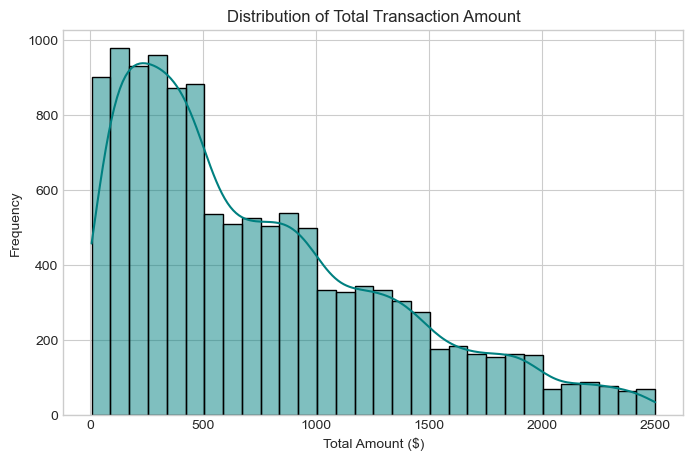

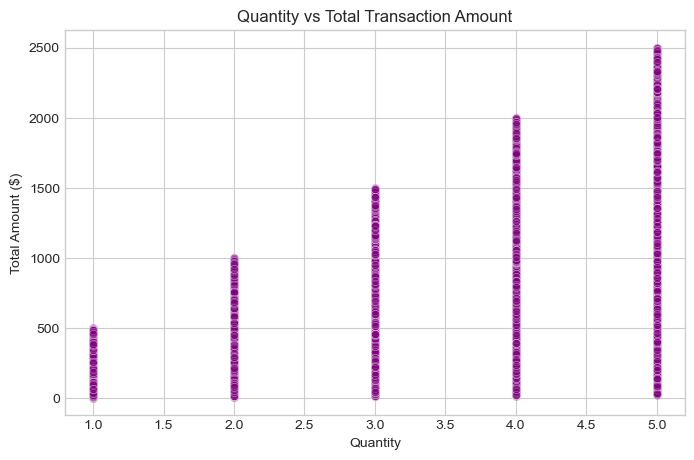

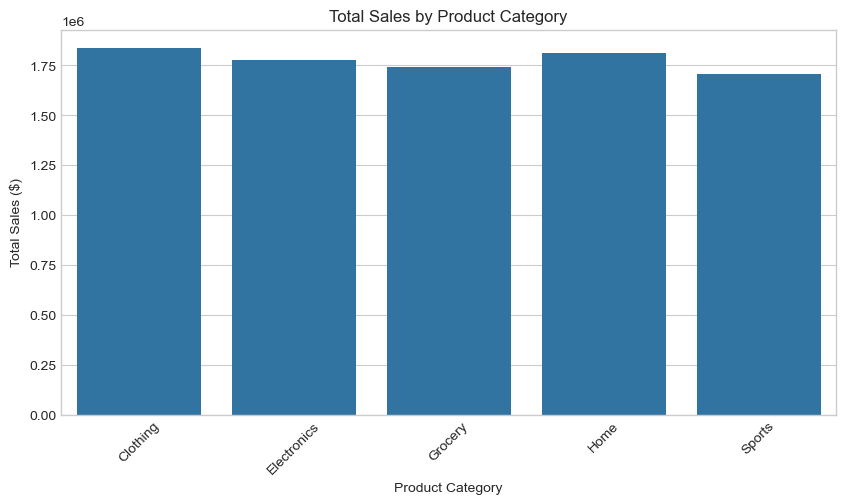

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')


plt.figure(figsize=(8,5))
sns.histplot(df['TotalAmount'], bins=30, kde=True, color='teal')
plt.title('Distribution of Total Transaction Amount')
plt.xlabel('Total Amount ($)')
plt.ylabel('Frequency')
plt.show()


plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='Quantity',
    y='TotalAmount',
    alpha=0.5,
    color='purple'
)
plt.title('Quantity vs Total Transaction Amount')
plt.xlabel('Quantity')
plt.ylabel('Total Amount ($)')
plt.show()


plt.figure(figsize=(10,5))

category_sales = (
    df.groupby('ProductCategory')['TotalAmount']
      .sum()
      .reset_index()
)

sns.barplot(
    data=category_sales,
    x='ProductCategory',
    y='TotalAmount'
)

plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.show()

Correlation Matrix:
                  Age  Quantity     Price  TotalAmount
Age          1.000000 -0.009959 -0.005234    -0.008820
Quantity    -0.009959  1.000000 -0.007378     0.596584
Price       -0.005234 -0.007378  1.000000     0.720344
TotalAmount -0.008820  0.596584  0.720344     1.000000


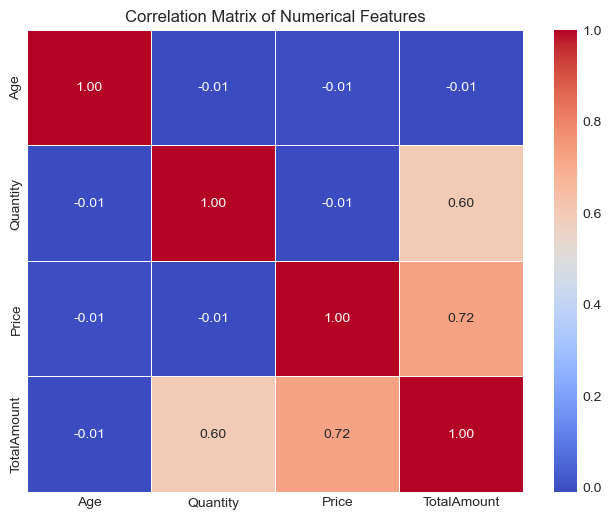

In [15]:

numeric_cols = ['Age', 'Quantity', 'Price', 'TotalAmount']


corr_matrix = df[numeric_cols].corr()

print("Correlation Matrix:")
print(corr_matrix)


plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Features')
plt.savefig('correlation_heatmap.png')
plt.show()

In [18]:
from mlxtend.frequent_patterns import apriori, association_rules


basket = pd.crosstab(
    df['TransactionID'],
    df['ProductCategory']
)


basket = basket.map(lambda x: 1 if x > 0 else 0)


frequent_itemsets = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)


frequent_itemsets = frequent_itemsets.sort_values(
    by='support',
    ascending=False
)

print("Top 10 Frequent Itemsets:")
print(frequent_itemsets.head(10))

Top 10 Frequent Itemsets:
    support                  itemsets
3  0.207917         frozenset({Home})
0  0.203667     frozenset({Clothing})
1  0.199417  frozenset({Electronics})
2  0.195333      frozenset({Grocery})
4  0.193667       frozenset({Sports})


C:\Users\kesha\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [19]:

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)
rules = rules.sort_values(by='lift', ascending=False)

print("Top Association Rules:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Top Association Rules:
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd



X = df[
    [
        'Age',
        'Quantity',
        'Price',
        'TotalAmount'
    ]
]



y = df['ProductCategory_Encoded']



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



dt_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

dt_model.fit(X_train, y_train)



y_pred = dt_model.predict(X_test)



print("Accuracy Score:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})


print("\nFeature Importance:")
print(
    feature_importance.sort_values(
        by='Importance',
        ascending=False
    )
)

Accuracy Score: 0.20833333333333334

Classification Report:
              precision    recall  f1-score   support

           0       0.21      0.07      0.10       478
           1       0.00      0.00      0.00       501
           2       0.18      0.13      0.15       470
           3       0.21      0.81      0.34       500
           4       0.14      0.00      0.00       451

    accuracy                           0.21      2400
   macro avg       0.15      0.20      0.12      2400
weighted avg       0.15      0.21      0.12      2400


Feature Importance:
       Feature  Importance
3  TotalAmount    0.397026
2        Price    0.383225
0          Age    0.219749
1     Quantity    0.000000


C:\Users\kesha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kesha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kesha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
